# Grid Strategy Backtester Notebook

This notebook uses the repo's `grid_strategy_backtester.py` directly so the notebook and script stay in sync.

Use it to:

- change strategy inputs in one cell
- run baseline vs improved backtests inline
- inspect summary, equity, and trades
- render the equity curve and diagnostics chart
- optionally export CSV and PNG outputs


## What Changed In This Version

- Inventory is now split into protected `core` lots and tradable `grid` lots.
- Normal profit-taking sells only unwind `grid` lots, not the protected core.
- `normal_max_qty` now controls the transition from `NORMAL` to `CAUTION`.
- `caution_max_qty` now controls the transition from `CAUTION` to `RECOVERY`.
- `hard_max_qty` is now a strict projected inventory cap for improved mode.
- The backtest fails fast if `starting_cash` cannot fund the initial buy.
- Repair logic now removes the highest-cost lot in the internal lot book instead of using LIFO for repair sells.
- Intrabar execution is configurable with `optimistic`, `one_order_per_candle`, `conservative`, and `close_only`.


In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if (repo_root / "notebooks").exists():
    repo_root = repo_root
elif (repo_root.parent / "grid_strategy_backtester.py").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from grid_strategy_backtester import (
    BacktestConfig,
    compare_baseline_vs_improved_dynamic,
    config_to_dict,
    plot_backtest_result,
    plot_diagnostics,
)


In [2]:
# Edit this cell for each scenario.

symbol = "NSE:RELIANCE-EQ"
start = "2024-01-01"
end = "2026-01-31"
provider = "fyers"          # fyers | yfinance | yf | yahoo
resolution = "1"            # FYERS: 1, 5, 15, D | yfinance: 1 => 1m
starting_cash = None         # Leave None when using capital_allocated-based capping
output_prefix = None

cfg = BacktestConfig(
    symbol=symbol,
    capital_allocated=1_000_000,
    initial_capital_frac=0.50,
    core_capital_frac=0.20,
    chunk_capital_frac=0.03,
    normal_capital_frac=0.50,
    caution_capital_frac=0.75,
    hard_capital_frac=0.95,
    chunk_qty=70,  # Fallback when chunk_capital/chunk_capital_frac is not set
    initial_qty=420,  # Fallback when initial_capital_frac is not set
    core_qty=420,  # Fallback when core_capital_frac is not set
    grid_pct=0.005,
    min_profit_pct=0.006,
    fee_per_share=0.0,
    mtf_interest_annual=0.0,
    mtf_leverage=3.0,
    runway_pct=0.05,
    normal_max_qty=560,
    caution_max_qty=840,
    hard_max_qty=1050,
    recovery_extra_sell_qty=70,
    allow_repair=False,
    repair_profit_fraction=0.50,
    use_intrabar=True,
    intrabar_mode="conservative",  # optimistic | one_order_per_candle | conservative | close_only
)

display(pd.DataFrame([asdict(cfg)]))

,symbol,capital_allocated,chunk_qty,initial_qty,core_qty,initial_capital_frac,core_capital_frac,chunk_capital,chunk_capital_frac,grid_pct,...,normal_max_qty,caution_max_qty,hard_max_qty,recovery_extra_sell_qty,recovery_extra_sell_capital,runway_pct,allow_repair,repair_profit_fraction,use_intrabar,intrabar_mode
0,NSE:RELIANCE-EQ,1000000,70,420,420,0.5,0.2,None,0.03,0.005,...,560,840,1050,70,None,0.05,False,0.5,True,conservative


In [3]:
result = compare_baseline_vs_improved_dynamic(
    symbol=symbol,
    start=start,
    end=end,
    provider=provider,
    resolution=resolution,
    starting_cash=starting_cash,
    output_prefix=output_prefix,
    cfg=cfg,
)

config_df = pd.DataFrame([
    config_to_dict(
        cfg=cfg,
        starting_cash=starting_cash,
        provider=provider,
        resolution=resolution,
        start=start,
        end=end,
    )
])

print("CONFIG USED")
display(config_df.T)
print("SUMMARY")
display(result["summary"])


  [fyers] 2024-01-01 → 2024-04-09: 25,605 candles
  [fyers] 2024-04-10 → 2024-07-18: 24,855 candles
  [fyers] 2024-07-19 → 2024-10-26: 25,875 candles
  [fyers] 2024-10-27 → 2025-02-03: 25,560 candles
  [fyers] 2025-02-04 → 2025-05-14: 24,375 candles
  [fyers] 2025-05-15 → 2025-08-22: 26,625 candles
  [fyers] 2025-08-23 → 2025-11-30: 24,436 candles
  [fyers] 2025-12-01 → 2026-01-31: 15,750 candles
CONFIG USED


,0
symbol,NSE:RELIANCE-EQ
start,2024-01-01
end,2026-01-31
provider,fyers
resolution,1
starting_cash,None
capital_allocated,1000000
chunk_qty,70
chunk_capital,None
chunk_capital_frac,0.03


SUMMARY


,strategy,final_total_pnl,max_drawdown,max_open_qty,max_grid_open_qty,final_open_qty,final_core_open_qty,final_grid_open_qty,final_breakeven_price,realized_grid_pnl,total_interest,total_fees,number_of_trades,number_of_sells,sell_win_rate
0,baseline,-6998.864497,-823283.594206,1988,1988,1988,0,1988,1400.520556,50048.937798,0.0,0.0,47859,44,1.0
1,improved,42058.030335,-658413.897684,1620,1466,1606,154,1452,1370.811936,71772.790139,0.0,0.0,150,44,1.0


Saved equity chart: grid_backtest_NSE_RELIANCE_EQ_2024-01-01_2026-01-31_fyers_equity_curve.png
Saved diagnostics chart: grid_backtest_NSE_RELIANCE_EQ_2024-01-01_2026-01-31_fyers_diagnostics.png


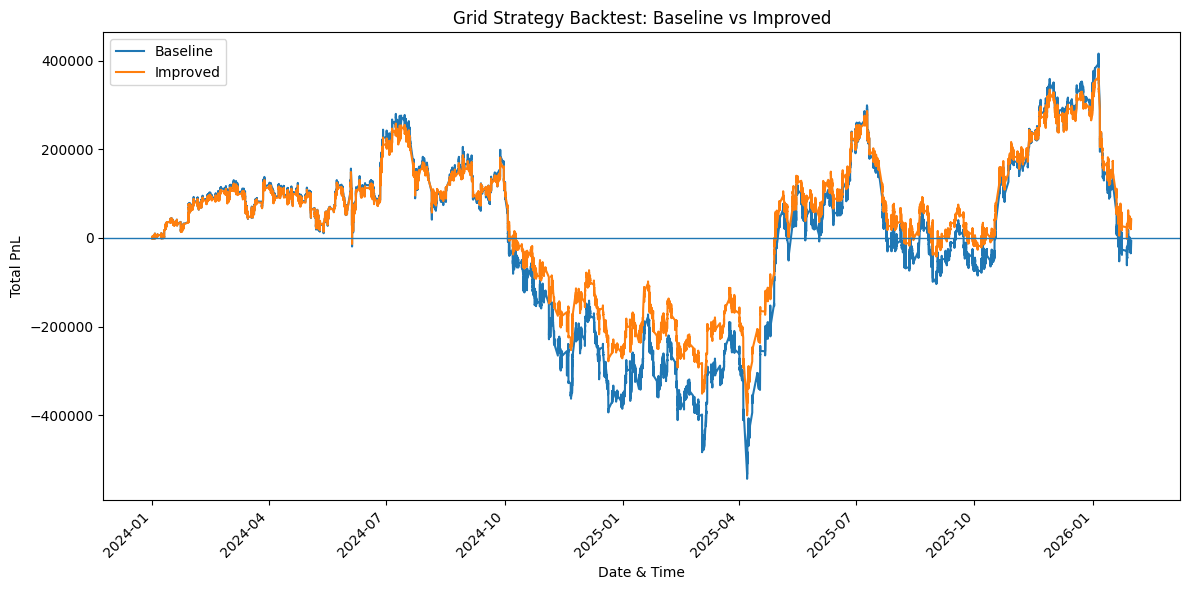

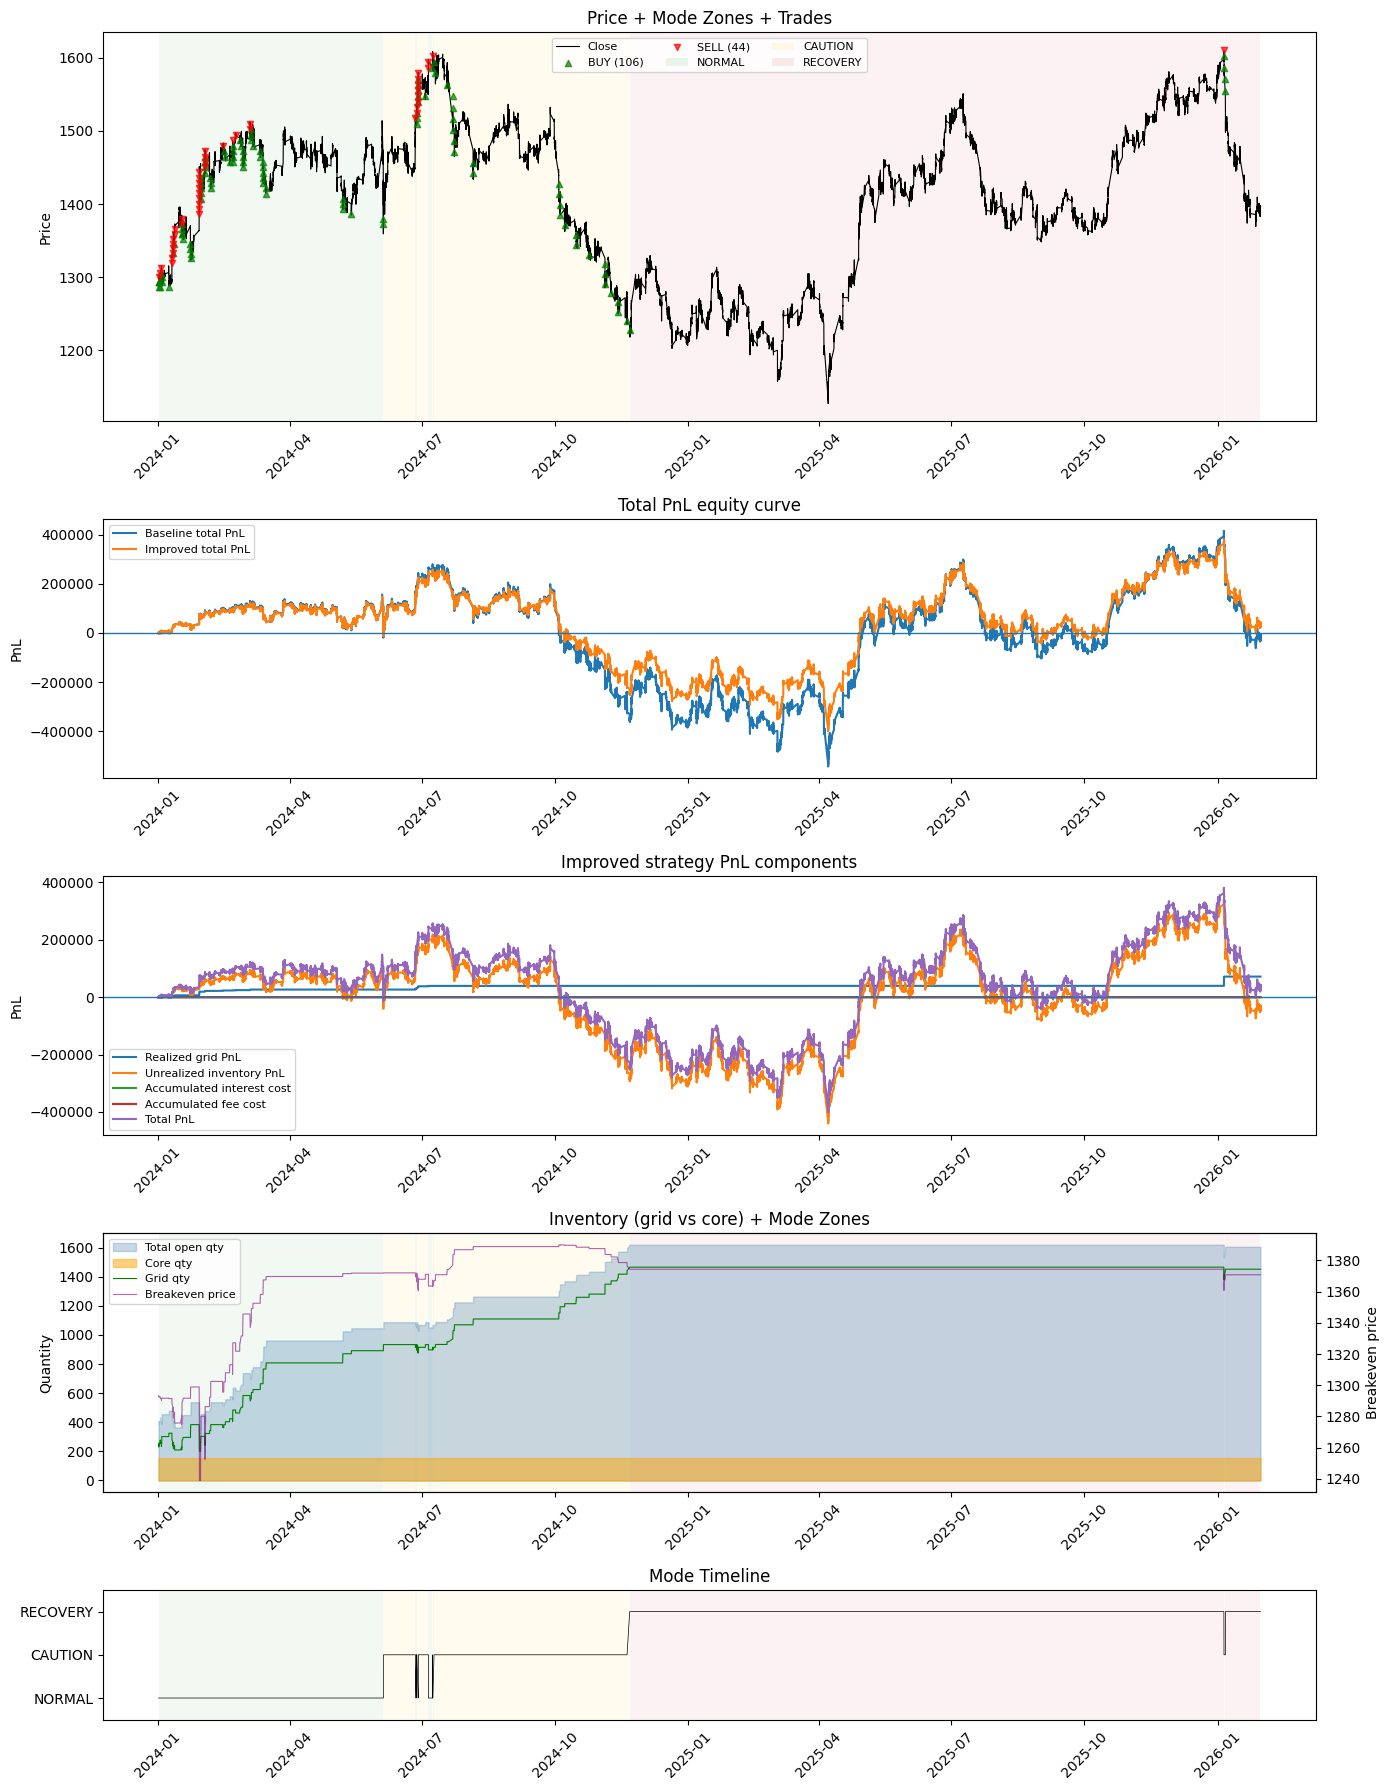

In [4]:
equity_chart_path = plot_backtest_result(result)
diagnostics_chart_path = plot_diagnostics(result)

print(f"Saved equity chart: {equity_chart_path}")
print(f"Saved diagnostics chart: {diagnostics_chart_path}")


In [5]:
print("Improved strategy trades")
display(result["improved_trades"].tail(20))

print("Improved strategy equity")
display(result["improved_equity"].tail(20))


Improved strategy trades


,datetime,side,qty,price,reason,lot_tag,mode,last_buy_price_after,last_sell_price_after,open_qty_after,core_open_qty_after,grid_open_qty_after,realized_grid_pnl_after,realized_this_sell,sold_lot_tag
130,2024-10-03 13:26:00,BUY,21,1413.465944,caution grid buy,grid,CAUTION,1413.465944,1602.654595,1306,154,1152,39603.079863,NaN,NaN
131,2024-10-04 09:16:00,BUY,21,1399.331284,caution grid buy,grid,CAUTION,1399.331284,1602.654595,1327,154,1173,39603.079863,NaN,NaN
132,2024-10-04 09:17:00,BUY,21,1385.337972,caution grid buy,grid,CAUTION,1385.337972,1602.654595,1348,154,1194,39603.079863,NaN,NaN
133,2024-10-07 13:03:00,BUY,21,1371.484592,caution grid buy,grid,CAUTION,1371.484592,1602.654595,1369,154,1215,39603.079863,NaN,NaN
134,2024-10-15 09:16:00,BUY,22,1357.769746,caution grid buy,grid,CAUTION,1357.769746,1602.654595,1391,154,1237,39603.079863,NaN,NaN
135,2024-10-15 14:09:00,BUY,22,1344.192048,caution grid buy,grid,CAUTION,1344.192048,1602.654595,1413,154,1259,39603.079863,NaN,NaN
136,2024-10-24 09:41:00,BUY,22,1330.750128,caution grid buy,grid,CAUTION,1330.750128,1602.654595,1435,154,1281,39603.079863,NaN,NaN
137,2024-11-04 09:16:00,BUY,22,1317.442627,caution grid buy,grid,CAUTION,1317.442627,1602.654595,1457,154,1303,39603.079863,NaN,NaN
138,2024-11-04 09:43:00,BUY,23,1304.268200,caution grid buy,grid,CAUTION,1304.268200,1602.654595,1480,154,1326,39603.079863,NaN,NaN
139,2024-11-04 10:26:00,BUY,23,1291.225518,caution grid buy,grid,CAUTION,1291.225518,1602.654595,1503,154,1349,39603.079863,NaN,NaN


Improved strategy equity


,datetime,close,mode,open_qty,core_open_qty,grid_open_qty,avg_cost,core_avg_cost,grid_avg_cost,core_open_cost,...,gross_exposure_limit,current_exposure,available_exposure,exposure_ratio,mtf_borrowed_amount,mtf_borrowed_fraction,total_pnl,breakeven_price,cash,cash_usage_ratio
193061,2026-01-30 15:10:00,1395.5,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,39649.030335,1370.811936,-2.201524e+06,0.757766
193062,2026-01-30 15:11:00,1395.6,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,39809.630335,1370.811936,-2.201524e+06,0.757766
193063,2026-01-30 15:12:00,1396.1,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,40612.630335,1370.811936,-2.201524e+06,0.757766
193064,2026-01-30 15:13:00,1396.5,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,41255.030335,1370.811936,-2.201524e+06,0.757766
193065,2026-01-30 15:14:00,1396.0,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,40452.030335,1370.811936,-2.201524e+06,0.757766
193066,2026-01-30 15:15:00,1396.4,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,41094.430335,1370.811936,-2.201524e+06,0.757766
193067,2026-01-30 15:16:00,1397.7,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,43182.230335,1370.811936,-2.201524e+06,0.757766
193068,2026-01-30 15:17:00,1397.1,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,42218.630335,1370.811936,-2.201524e+06,0.757766
193069,2026-01-30 15:18:00,1397.3,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,42539.830335,1370.811936,-2.201524e+06,0.757766
193070,2026-01-30 15:19:00,1396.9,RECOVERY,1606,154,1452,1415.502341,1293.3,1428.463195,199168.2,...,3000000.0,2.273297e+06,726703.240196,0.757766,1.515531e+06,0.666667,41897.430335,1370.811936,-2.201524e+06,0.757766


In [6]:
improved_trades = result["improved_trades"].copy()
improved_equity = result["improved_equity"].copy()

overlay_trades = improved_trades[
    (improved_trades.get("lot_tag") == "grid") |
    (improved_trades.get("sold_lot_tag") == "grid")
].copy()

overlay_summary = pd.DataFrame([
    {
        "metric": "final_core_qty",
        "value": improved_equity["core_open_qty"].iloc[-1],
    },
    {
        "metric": "final_grid_qty",
        "value": improved_equity["grid_open_qty"].iloc[-1],
    },
    {
        "metric": "realized_grid_pnl",
        "value": improved_equity["realized_grid_pnl"].iloc[-1],
    },
    {
        "metric": "final_grid_unrealized_pnl",
        "value": improved_equity["grid_unrealized_pnl"].iloc[-1],
    },
    {
        "metric": "final_core_unrealized_pnl",
        "value": improved_equity["core_unrealized_pnl"].iloc[-1],
    },
    {
        "metric": "final_overlay_pnl_before_costs",
        "value": improved_equity["realized_grid_pnl"].iloc[-1] + improved_equity["grid_unrealized_pnl"].iloc[-1],
    },
    {
        "metric": "final_total_pnl_after_costs",
        "value": improved_equity["total_pnl"].iloc[-1],
    },
])

print("Overlay summary")
display(overlay_summary)

print("Overlay-only trades")
display(overlay_trades.tail(30))


Overlay summary


,metric,value
0,final_core_qty,154.000000
1,final_grid_qty,1452.000000
2,realized_grid_pnl,71772.790139
3,final_grid_unrealized_pnl,-45684.559804
4,final_core_unrealized_pnl,15969.800000
5,final_overlay_pnl_before_costs,26088.230335
6,final_total_pnl_after_costs,42058.030335


Overlay-only trades


,datetime,side,qty,price,reason,lot_tag,mode,last_buy_price_after,last_sell_price_after,open_qty_after,core_open_qty_after,grid_open_qty_after,realized_grid_pnl_after,realized_this_sell,sold_lot_tag
120,2024-07-18 09:29:00,BUY,19,1562.907960,caution grid buy,grid,CAUTION,1562.907960,1602.654595,1108,154,954,39603.079863,NaN,NaN
121,2024-07-22 09:15:00,BUY,19,1547.278880,caution grid buy,grid,CAUTION,1547.278880,1602.654595,1127,154,973,39603.079863,NaN,NaN
122,2024-07-22 09:16:00,BUY,19,1531.806091,caution grid buy,grid,CAUTION,1531.806091,1602.654595,1146,154,992,39603.079863,NaN,NaN
123,2024-07-22 09:17:00,BUY,19,1516.488031,caution grid buy,grid,CAUTION,1516.488031,1602.654595,1165,154,1011,39603.079863,NaN,NaN
124,2024-07-22 12:31:00,BUY,19,1501.323150,caution grid buy,grid,CAUTION,1501.323150,1602.654595,1184,154,1030,39603.079863,NaN,NaN
125,2024-07-23 10:24:00,BUY,20,1486.309919,caution grid buy,grid,CAUTION,1486.309919,1602.654595,1204,154,1050,39603.079863,NaN,NaN
126,2024-07-23 12:20:00,BUY,20,1471.446820,caution grid buy,grid,CAUTION,1471.446820,1602.654595,1224,154,1070,39603.079863,NaN,NaN
127,2024-08-05 09:30:00,BUY,20,1456.732351,caution grid buy,grid,CAUTION,1456.732351,1602.654595,1244,154,1090,39603.079863,NaN,NaN
128,2024-08-05 12:02:00,BUY,20,1442.165028,caution grid buy,grid,CAUTION,1442.165028,1602.654595,1264,154,1110,39603.079863,NaN,NaN
129,2024-10-03 12:18:00,BUY,21,1427.743378,caution grid buy,grid,CAUTION,1427.743378,1602.654595,1285,154,1131,39603.079863,NaN,NaN


In [7]:
# Optional export of all CSV outputs already produced by compare_baseline_vs_improved_dynamic.
# Use this cell if you also want a config CSV from inside the notebook.

save_config_csv = False

if save_config_csv:
    config_path = f"{result['output_prefix']}_config.csv"
    config_df.to_csv(config_path, index=False)
    print(f"Saved config: {config_path}")
